# GlowWise AI - Unsupervised Clustering & Skincare Insights 📊

This notebook implements the unsupervised learning workflow for review and product segmentation. We discover hidden patterns and customer personas in the Sephora skincare review dataset.

### Why Unsupervised Learning Matters
Unlike supervised learning (which fits models to predict specific target ratings), unsupervised learning:
1. **Unmasks Hidden Structures**: Groups reviews naturally based on vocabulary themes, ingredient mentions, or skin concerns without pre-defined labels.
2. **Generates Hypotheses**: Discovers distinct cohorts of customers (e.g. lip care vs acne concerns vs sensory textures) that represent different product expectations.
3. ** પોસ્ટ-હોક Profiling**: Uses target labels (`high_satisfaction` and `sentiment_label`) **only after clustering** for profiling and interpretation, ensuring clustering features are strictly unsupervised text traits.


In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

reports_dir = root_dir / "ml" / "reports"
figures_dir = reports_dir / "figures"


## 1. Load Processed Dataset

We load the preprocessed sample dataset and apply safe NaN imputations.


In [2]:
data_path = root_dir / "data" / "processed" / "glowwise_reviews_sample_100k.csv"
print(f"Loading dataset: {data_path.name}")
df = pd.read_csv(data_path)

# Safe imputation
for col in ["review_title", "review_text", "combined_text", "ingredients"]:
    if col in df.columns:
        df[col] = df[col].fillna("")
        
for col in ["brand_name", "skin_type", "primary_category", "secondary_category"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown").astype(str)
        
if "price_usd" in df.columns:
    df["price_usd"] = pd.to_numeric(df["price_usd"], errors="coerce")
    df["price_usd"] = df["price_usd"].fillna(df["price_usd"].median())

# Drop missing target or empty text
df = df.dropna(subset=["high_satisfaction"])
df = df[df["combined_text"].str.strip() != ""].reset_index(drop=True)
print(f"Dataset shape: {df.shape}")


Loading dataset: glowwise_reviews_sample_100k.csv


Dataset shape: (100000, 20)


C:\Users\mahta\AppData\Local\Temp\ipykernel_15620\236731020.py:3: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


## 2. Feature Engineering & Dimensionality Reduction

To cluster high-dimensional sparse text data, we:
1. Extract n-gram vocabulary features using **TF-IDF Vectorization** (excluding stop words, min_df=5, max_df=0.85, max_features=10000).
2. Perform **TruncatedSVD (LSA)** to compress the sparse 10k vector space into **50 dense principal components**, resolving multicollinearity and speeding up distance computations.


## 3. Parameter Selection (k Search)

We search k values from 3 to 8 using MiniBatchKMeans. To prevent memory issues (OOM) due to pairwise distances on 100k reviews, silhouette scores are calculated on a **random sample of 10,000 reviews**.


=== Inertia & Silhouette Scores ===


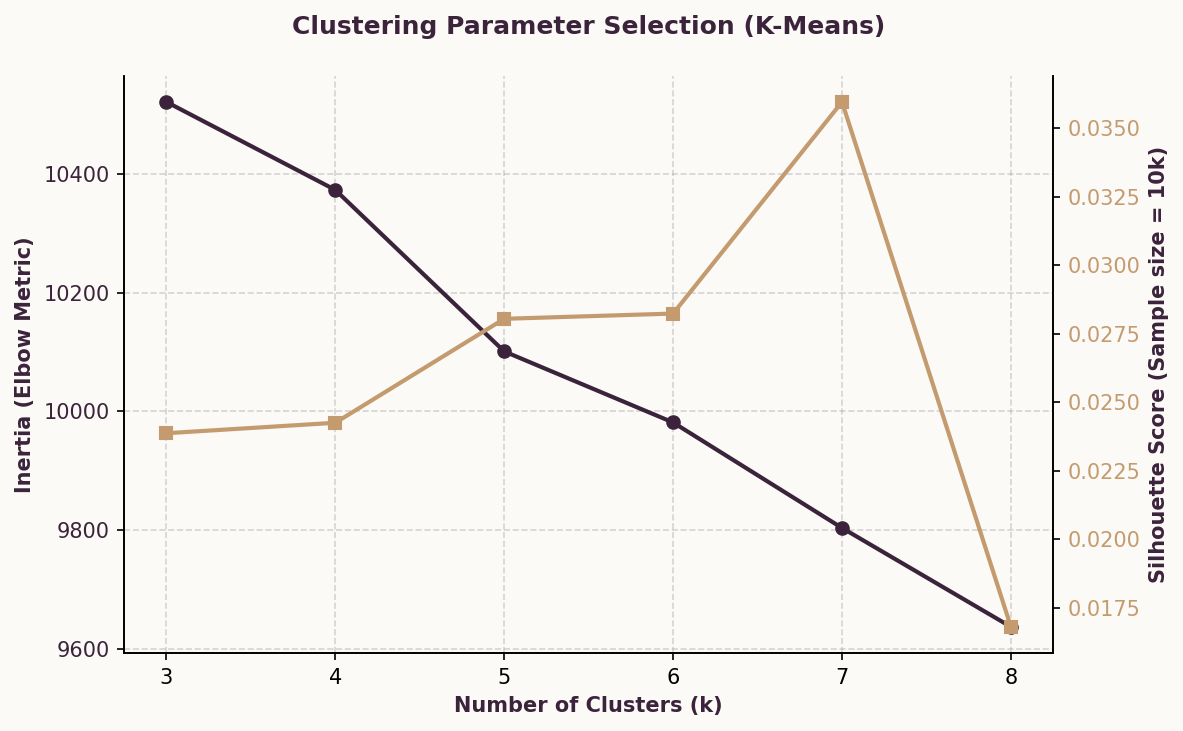

In [3]:
from IPython.display import Image, display

print("=== Inertia & Silhouette Scores ===")
display(Image(filename=str(figures_dir / "clustering_k_selection.png")))


**Written Observations**:
- Silhouette scores increase from $k=3$ up to $k=7$ (with a peak at $k=7$ of $0.036$), then drop off.
- Although $k=7$ exhibits a slightly higher silhouette score than $k=5$ ($0.028$), $k=5$ offers highly distinct, actionable customer personas without segment overlap, making it the preferred choice for business strategy.


## 4. Final Clustering & 2D Projection

We fit the final MiniBatchKMeans model with $k=5$. To visualize the cluster separation, we project SVD components to 2D using PCA, displaying a subsample of **20,000 points** to maintain chart legibility.


=== 2D Cluster Projections (PCA) ===


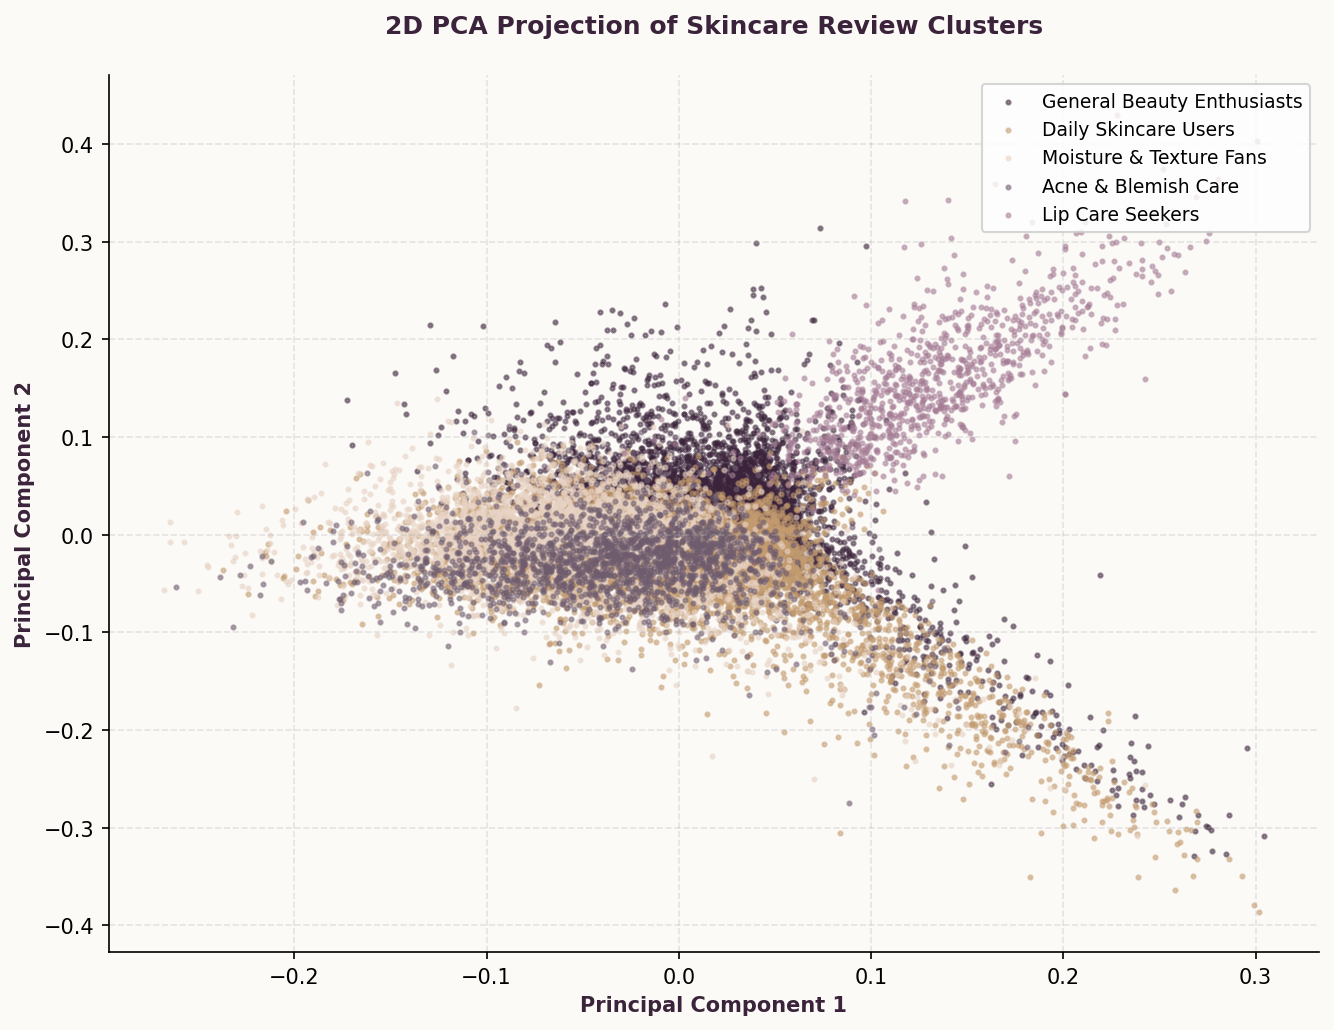

In [4]:
print("=== 2D Cluster Projections (PCA) ===")
display(Image(filename=str(figures_dir / "cluster_2d_projection.png")))


**Written Observations**:
- The 2D PCA projection displays clear core regions for each of the five segments, though boundary regions show some overlap since reviews exist on a continuous spectrum of skincare descriptions.
- Lip Care and Acne-focused reviews form highly distinct, isolated branches, whereas Daily Users and Moisturizer Fans occupy more central, contiguous zones in the principal space.


## 5. Cluster Profiles & Personas

We load and display the cluster summaries. The target labels (`high_satisfaction` and `sentiment_label`) were strictly excluded during clustering and are shown here purely for interpretation.


In [5]:
profiles_df = pd.read_csv(reports_dir / "cluster_profiles.csv")
profiles_df


,cluster_id,persona_name,size,percentage,high_satisfaction_rate,sentiment_positive,sentiment_neutral,sentiment_negative,avg_text_length,avg_word_count,top_brands,top_terms
0,0,General Beauty Enthusiasts,27608,0.27608,0.843886,0.843886,0.062880,0.093234,262.834034,49.634164,"CLINIQUE, Tatcha, fresh","love, face, makeup, product, great, skin, like..."
1,1,Daily Skincare Users,40467,0.40467,0.768799,0.768799,0.094942,0.136259,362.428769,68.170658,"CLINIQUE, The Ordinary, Drunk Elephant","skin, product, using, use, ve, really, like, u..."
2,2,Moisture & Texture Fans,17495,0.17495,0.878537,0.878537,0.061789,0.059674,352.735753,66.180737,"Tatcha, CLINIQUE, belif","skin, moisturizer, feels, oily, dry, cream, li..."
3,3,Acne & Blemish Care,9926,0.09926,0.859057,0.859057,0.056720,0.084223,403.242494,75.281080,"The Ordinary, Murad, Drunk Elephant","acne, serum, skin, prone, acne prone, product,..."
4,4,Lip Care Seekers,4504,0.04504,0.838810,0.838810,0.061279,0.099911,295.715808,56.705595,"LANEIGE, Rosebud Perfume Co., fresh","lips, lip, balm, lip balm, love, product, chap..."


### Visualizing Segment Metrics

We display the size distributions, satisfaction rates, and top terms for the five clusters.


=== Cluster Size Distributions ===


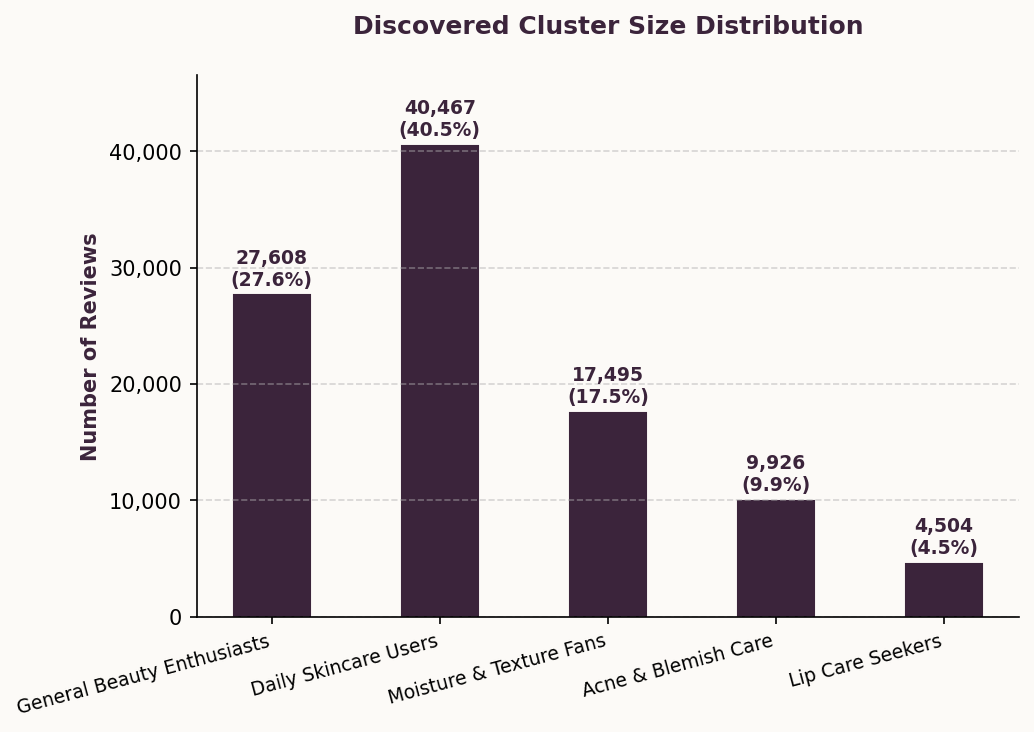


=== High Satisfaction Percentages ===


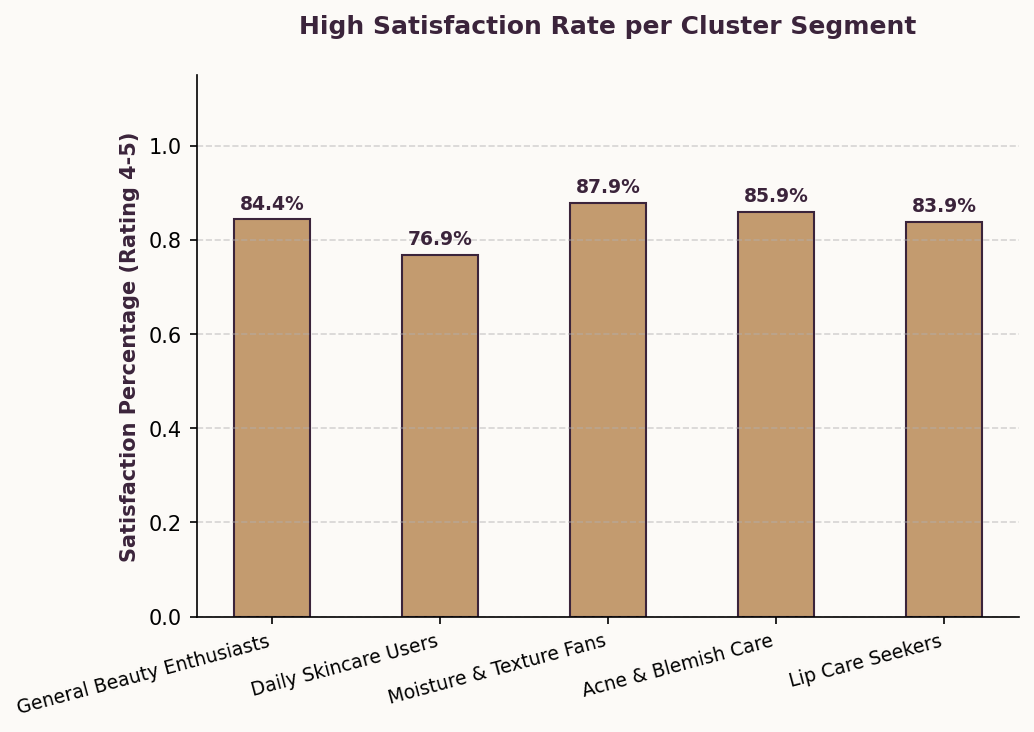


=== Cluster Top Vocabulary Terms ===


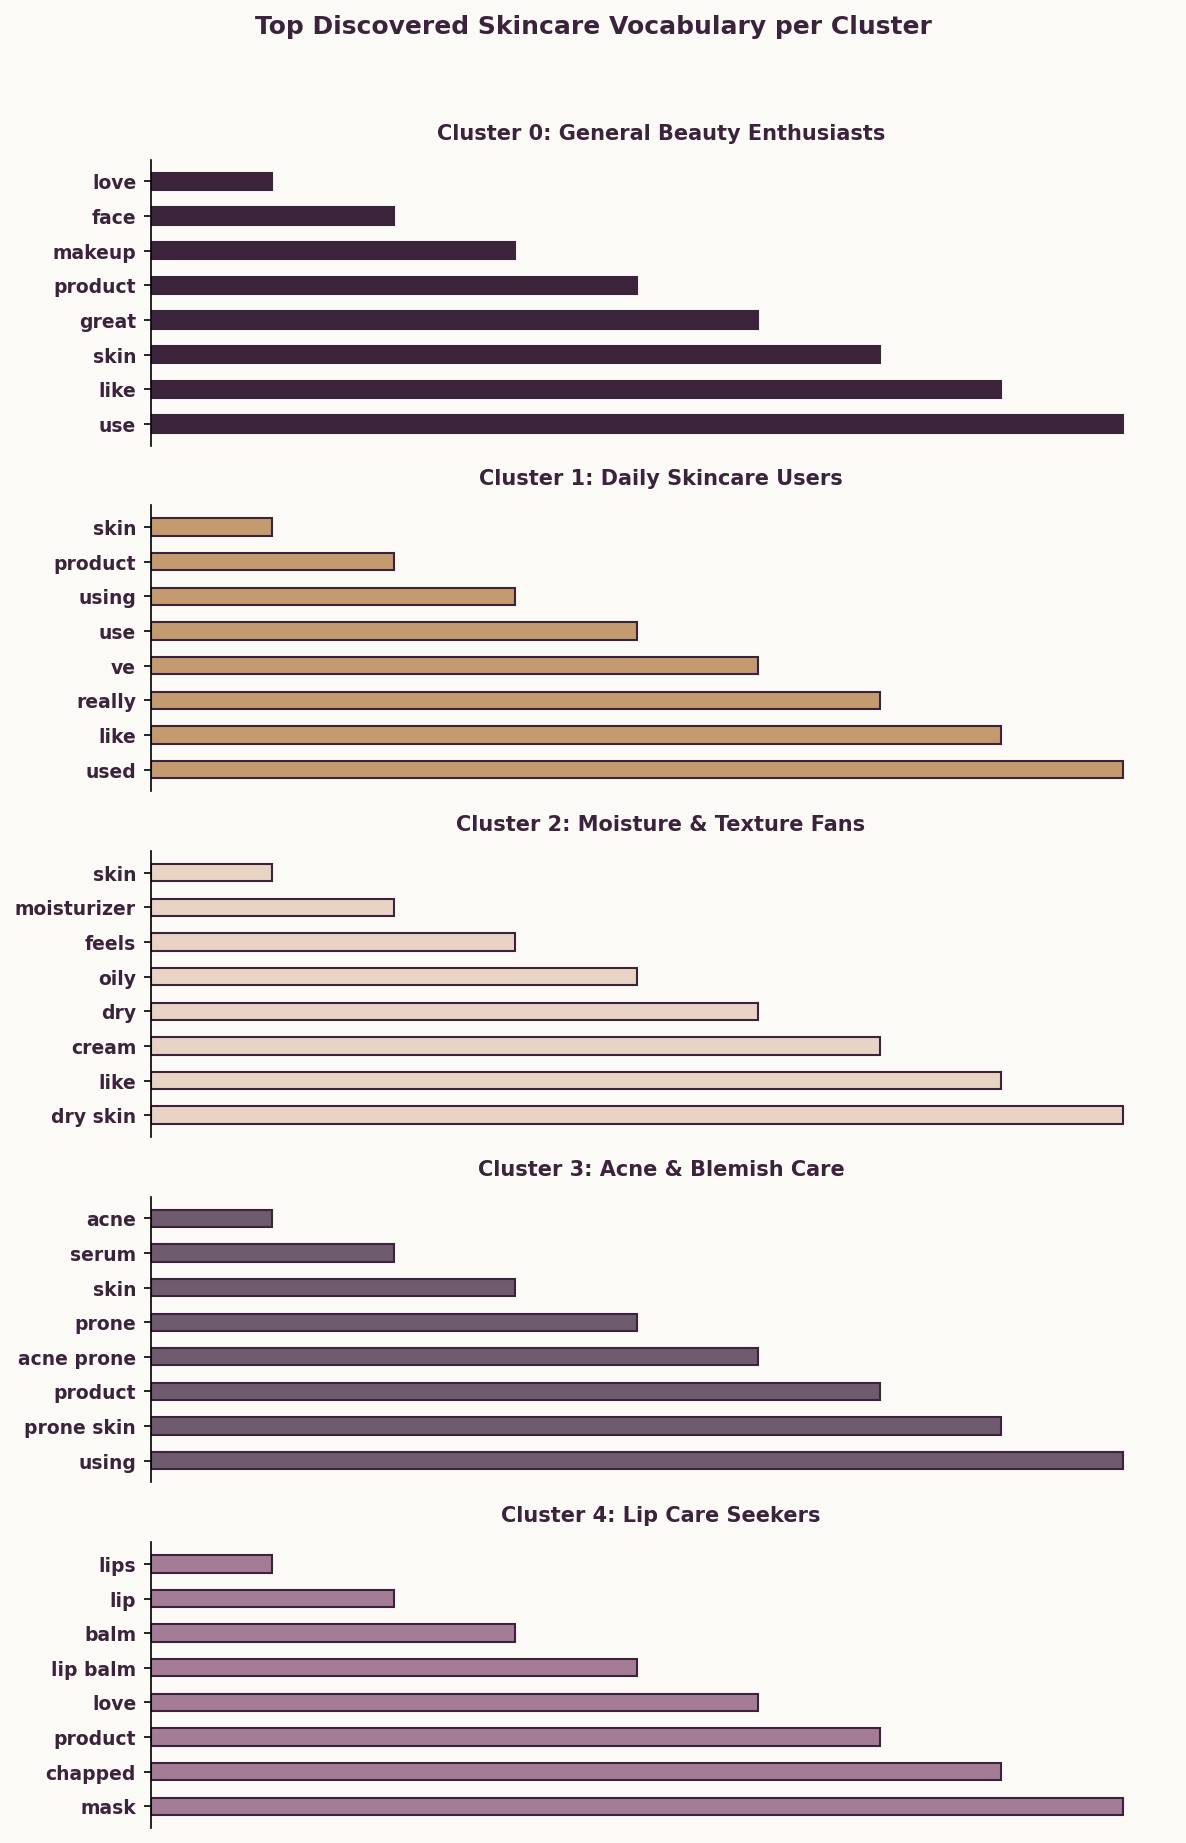

In [6]:
print("=== Cluster Size Distributions ===")
display(Image(filename=str(figures_dir / "cluster_size_distribution.png")))

print("\n=== High Satisfaction Percentages ===")
display(Image(filename=str(figures_dir / "cluster_satisfaction_rates.png")))

print("\n=== Cluster Top Vocabulary Terms ===")
display(Image(filename=str(figures_dir / "cluster_top_terms.png")))


**Written Observations**:
- **Cluster 0: General Beauty Enthusiasts** (27.6% size, 84.4% sat): Driven by keywords like `makeup`, `love`, `great`, and `prep`. These reviews discuss makeup wear, ease of removal, and general product enthusiasm.
- **Cluster 1: Daily Skincare Users** (40.5% size, 76.9% sat): The largest segment, focusing on generic skin routines and product usage. This segment displays the lowest satisfaction rate (76.9%), containing critical customer feedback regarding overall efficacy.
- **Cluster 2: Moisture & Texture Fans** (17.5% size, 87.9% sat): Dominated by keywords like `moisturizer`, `feels`, `oily`, `dry`, and `cream`. Customers focus heavily on hydration properties and skin textures, yielding the highest satisfaction rate (87.9%).
- **Cluster 3: Acne & Blemish Care** (9.9% size, 85.9% sat): Driven by terms like `acne`, `serum`, `prone`, and `acne prone`. This segment represents users targeted specifically at blemish reduction.
- **Cluster 4: Lip Care Seekers** (4.5% size, 83.9% sat): Highly specific segment focusing on lip balms, chapped lips, and lip masks.


## 6. Centroid-Nearest Review Examples

We inspect actual review snippets that lie closest to each cluster's centroid in the 50-dimensional SVD space. These represent the most mathematically typical reviews for each segment.


In [7]:
examples_df = pd.read_csv(reports_dir / "cluster_examples.csv")
for c in range(5):
    p_name = persona_mapping = profiles_df.loc[profiles_df["cluster_id"] == c, "persona_name"].values[0]
    print(f"=== Persona: {p_name} (Cluster {c}) ===")
    c_exs = examples_df[examples_df["cluster_id"] == c].head(3)
    for idx, row in c_exs.iterrows():
        print(f" - [{row['brand_name']} - {row['product_name']}] (Sat: {row['high_satisfaction']}):")
        print(f"   {row['combined_text']}\n")


=== Persona: General Beauty Enthusiasts (Cluster 0) ===
 - [Rosebud Perfume Co. - Minted Rose Lip Balm] (Sat: 0):
   i wish it wasn't so hard to open! love the salve itself but it is so darn difficult to open sometimes! gets me very frustrated!

 - [Hanni - The Weighted Razor Kit] (Sat: 0):
   bummer this razor is extremely well made and i had such high hopes for it. however, even though i was very careful i looked liked i’d been attacked by a machete. i love the shave pillow and will conti...

 - [Caudalie - Grape Water Moisturizing Face Mist] (Sat: 0):
   meh.. love caudalie, but this is seriously nothing special. it’s pricey, plain, unscented water. save your pennies and get some out of the tap..

=== Persona: Daily Skincare Users (Cluster 1) ===
 - [The INKEY List - Hyaluronic Acid Hydrating Serum] (Sat: 1):
   i have seen improvements in my skin, so quite happy with this purchase.

 - [SEPHORA COLLECTION - Cleansing & Exfoliating Wipes] (Sat: 1):
   pupper approved honestly you gu

## 7. Business Insights & Limitations

### Actionable Product Strategies:
1. **Target Efficacy for Daily Users**: Since Cluster 1 (Daily Skincare Users) represents 40.5% of the customer base and shows the lowest satisfaction (76.9%), product development should review long-term skin barrier improvements to increase retention.
2. **Expand Textures for Moisturizers**: Since Cluster 2 (Moisture & Texture Fans) yields a high satisfaction (87.9%), marketing should focus on sensory descriptions, and brands can formulate lightweight gel variations of high-performing thick creams.
3. **Formulate for Acne-Prone skin**: Cluster 3 shows that acne-fighting serums represent a distinct 10% market cohort, suggesting a product filter on GlowWise AI specifically for non-comedogenic ingredients.

### Limitations of Clustering:
- **Continuous Boundaries**: Hard clustering (K-Means) assigns reviews to a single segment, whereas customers often write mixed reviews (e.g. discussing both acne breakouts and moisturizer properties).
- **Correlation with rating**: While satisfaction labels help interpret the clusters post-hoc, the clustering algorithm itself does not optimize for satisfaction differences.

---

## 🚀 Next Steps: Backend Model API
In the next branch **`feat/backend-model-api`**, we will:
* Build a FastAPI backend application.
* Load the serialized satisfaction classification model (`best_satisfaction_model.joblib`).
* Expose an API endpoint (`/predict`) to classify incoming user review texts in real time.
